# Phase 1 DoD — does seeded memory measurably shift DST answers?

One hypothesis: holding persona constant, two agents given opposite seeded memories answer the DST survey differently. Metric = **P(permanent-DST) delta** over K samples, with an **empty-memory control** proving memory (not persona) is the cause. Imports down from `src/polis`; nothing redefined here.

Note on option wording: an 8B model reasons fine about *earlier/later sunrises* but doesn't reliably know that "permanent daylight saving time" means later sunrises — the same confusion that makes real DST polls wording-sensitive. `polis.questions.DST_QUESTION` spells out the consequence so a memory-driven preference maps to the right option; with no memory the model picks neither pole.

In [1]:
from collections import Counter

import pandas as pd
from plotnine import (aes, coord_flip, geom_col, ggplot, labs, position_dodge,
                      theme_minimal)

from polis.agent import Agent
from polis.embeddings import EmbeddingModel
from polis.llm import LLMClient
from polis.memory import RetrievalConfig
from polis.memory_seeds import (EVENING_SEEDS, MORNING_SEEDS, SHARED_PERSONA,
                                build_store)
from polis.questions import DST_PERMANENT, DST_QUESTION

In [2]:
# --- config: edit and re-run downward ---
K_SAMPLES = 20            # samples per condition
TEMPERATURE = 0.8        # fixed across conditions so memory is the only mover
RETRIEVAL = RetrievalConfig()

QUESTION = DST_QUESTION            # canonical, consequence-annotated options
TARGET = DST_PERMANENT            # the option we track P() of

# Same persona everywhere; the memory set is the manipulated variable.
CONDITIONS = {
    "evening-seeds": EVENING_SEEDS,
    "morning-seeds": MORNING_SEEDS,
    "empty-control": [],
}

In [3]:
client = LLMClient()
embedder = EmbeddingModel()
print("embedding on:", embedder._ensure() and embedder.device, "| chat:", client.config.model)

C:\Users\Ryan R\Documents\DS_Projects_Local\AS-Technical-Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16520.53it/s]

embedding on: cuda | chat: qwen/qwen3-8b


## Sample each condition K times

A fresh agent per sample (fresh memory store) so R19 writeback from one sample never leaks into the next — each draw is independent given the seeds.

In [4]:
rows = []
for cond, seeds in CONDITIONS.items():
    for _ in range(K_SAMPLES):
        agent = Agent(
            SHARED_PERSONA, client,
            embedder=embedder,
            memory=build_store(embedder, seeds),
            retrieval=RETRIEVAL,
        )
        ans = agent.answer(QUESTION)
        rows.append({"condition": cond, "choice": ans.choice})

df = pd.DataFrame(rows)
df.groupby("condition")['choice'].value_counts()

condition      choice                                                                                                   
empty-control  Keep switching the clocks twice a year                                                                       20
evening-seeds  Adopt permanent daylight saving time (clocks stay on summer time all year: later sunrises, later sunsets)    20
morning-seeds  Adopt permanent standard time (clocks stay on winter time all year: earlier sunrises, earlier sunsets)       20
Name: count, dtype: int64

In [5]:
# P(permanent-DST) per condition and the headline delta between the seed sets.
p_dst = (df.assign(is_target=df['choice'].eq(TARGET))
           .groupby('condition')['is_target'].mean())
delta = p_dst['evening-seeds'] - p_dst['morning-seeds']
control = p_dst['empty-control']
print(p_dst.round(3).to_string())
print(f"\nP(permanent-DST) delta (evening - morning): {delta:+.3f}")
print(f"empty-control P(permanent-DST): {control:.3f}")

condition
empty-control    0.0
evening-seeds    1.0
morning-seeds    0.0

P(permanent-DST) delta (evening - morning): +1.000
empty-control P(permanent-DST): 0.000


## Choice distribution by condition

If memory is doing work, the evening-seeds bars lean to permanent DST and the morning-seeds bars lean to permanent standard time, with the empty control sitting on neither pole. Long option labels are truncated for the axis.

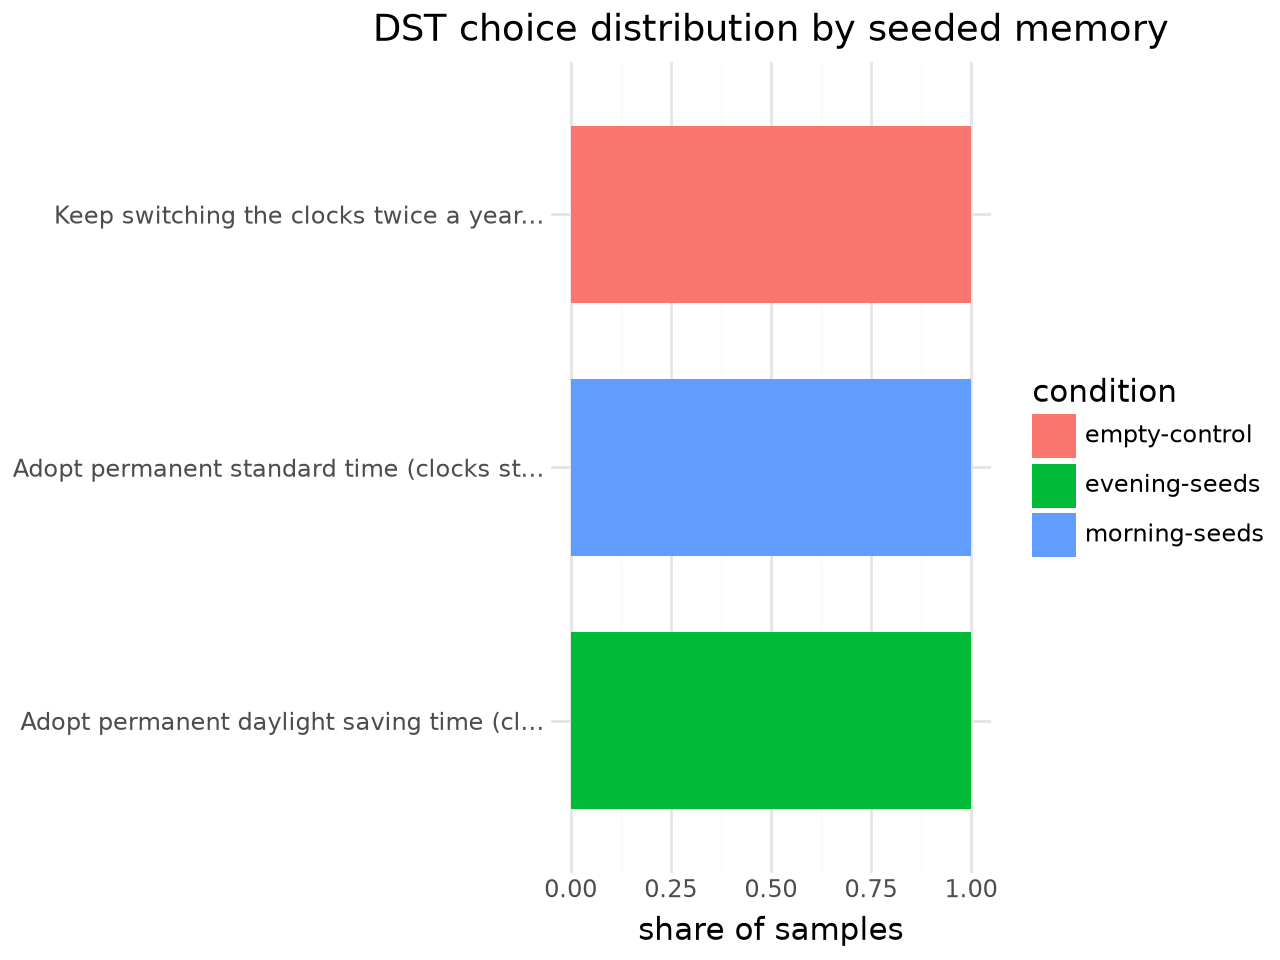

In [6]:
counts = df.groupby(['condition', 'choice']).size().rename('n').reset_index()
counts['share'] = counts['n'] / counts.groupby('condition')['n'].transform('sum')
counts['choice_short'] = counts['choice'].str.slice(0, 40) + '...'

(ggplot(counts, aes('choice_short', 'share', fill='condition'))
 + geom_col(position=position_dodge(width=0.8), width=0.7)
 + coord_flip()
 + labs(title='DST choice distribution by seeded memory',
        x='', y='share of samples', fill='condition')
 + theme_minimal())

## Verdict

**DoD met (K=20, qwen/qwen3-8b, temp 0.8).** Same persona, opposite seeded memories:

| condition | choice (20/20) | P(permanent-DST) |
|---|---|---|
| evening-seeds | permanent daylight saving time | 1.00 |
| morning-seeds | permanent standard time | 0.00 |
| empty-control | keep switching twice a year | 0.00 |

**P(permanent-DST) delta (evening − morning) = +1.000**, and the empty control sits on neither pole (100% "keep switching") — so the shift tracks the seeded memory, not the persona. Retrieval → injection → answer → R19 writeback all exercised. See `docs/checkpoints/phase-1.md`.

Caveat carried into the model-capability addendum (ADR 0005): the option labels spell out the sunrise/sunset consequence because 8B doesn't reliably map "permanent DST" → later sunrises; a same-family 8b→32b→72b sweep tests whether that annotation is still needed at larger sizes and whether the memory delta and neutral control survive.